# EcoType — Final Packaging Notebook

## Objective
This notebook presents the final packaged results of the Forest Cover Type Classification project, including:

- final selected model
- final evaluation metrics
- confusion matrix
- saved artifacts
- local run instructions
- final project checklist

This notebook is intended as the final demonstration layer for the project.

# Setup and imports

In [2]:
from pathlib import Path
import joblib
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

PROJECT_ROOT = Path.cwd().resolve().parents[0] if "notebooks" in str(Path.cwd()) else Path.cwd()

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FINAL_MODEL_PATH = MODELS_DIR / "random_forest_final_model.joblib"
X_TEST_PATH = PROCESSED_DIR / "X_test.csv"
Y_TEST_PATH = PROCESSED_DIR / "Y_test.csv"

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Load final artifacts

In [4]:
model = joblib.load(FINAL_MODEL_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print("Model loaded:", type(model))
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Model loaded: <class 'imblearn.pipeline.Pipeline'>
X_test shape: (29178, 20)
y_test shape: (29178,)


# Final predictions

In [5]:
y_pred = model.predict(X_test)

In [6]:
y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

# Final metrics

## Final Evaluation Metrics
The following metrics summarize the performance of the final selected model on the held-out test set.

In [7]:
final_accuracy = accuracy_score(y_test, y_pred)
final_macro_f1 = f1_score(y_test, y_pred, average="macro")
final_weighted_f1 = f1_score(y_test, y_pred, average="weighted")

metrics_df = pd.DataFrame(
    {
        "metric": ["accuracy", "macro_f1", "weighted_f1"],
        "value": [final_accuracy, final_macro_f1, final_weighted_f1],
    }
)

metrics_df

,metric,value
0,accuracy,0.959387
1,macro_f1,0.915157
2,weighted_f1,0.959041


In [8]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
Aspen,0.919383,0.872964,0.895572,614.000000
Cottonwood/Willow,0.949309,0.953704,0.951501,432.000000
Douglas-fir,0.825054,0.884259,0.853631,432.000000
Krummholz,0.934978,0.965278,0.949886,432.000000
Lodgepole Pine,0.967014,0.985544,0.976191,20614.000000
Ponderosa Pine,0.863208,0.847222,0.855140,432.000000
Spruce/Fir,0.956178,0.894246,0.924176,6222.000000
accuracy,0.959387,0.959387,0.959387,0.959387
macro avg,0.916446,0.914745,0.915157,29178.000000
weighted avg,0.959326,0.959387,0.959041,29178.000000


# Confusion Matrix

## Confusion Matrix
This plot shows where the final model predicts correctly and where class confusion still remains.

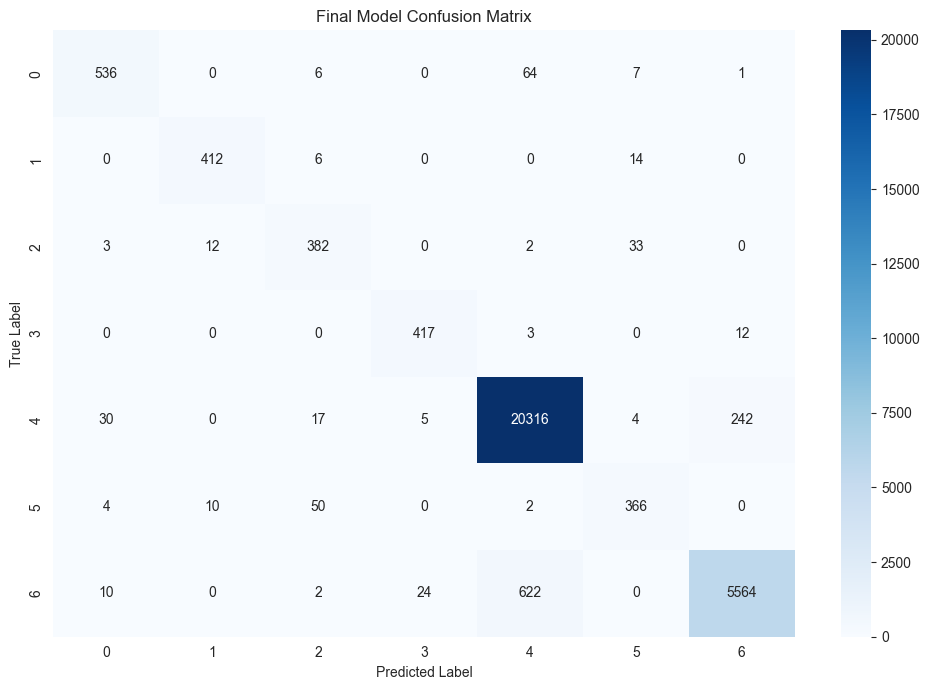

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Final Narrative Summary

This project built a machine learning pipeline to predict forest cover type from cartographic and environmental features.

### Workflow completed
- project setup and planning
- data understanding
- data cleaning and validation
- preprocessing pipeline
- feature engineering
- exploratory data analysis
- baseline model comparison
- imbalance-aware tuning / model selection
- final model evaluation
- inference packaging
- Streamlit deployment support

### Final model outcome
The selected final model was chosen based on cross-validation and final held-out test performance, with macro F1 used as the primary model selection metric.

### Why this model was selected
- strong overall performance
- stable class-wise behavior
- better balance across multiple forest cover classes
- suitable for deployment through serialized artifact loading

### Deliverables produced
- trained model artifact
- evaluation outputs
- comparison notebook(s)
- inference-ready pipeline
- Streamlit app support
- final packaging notebook